In [1]:
"""
FILE 5: COMBINE RESULTS & CREATE COMPREHENSIVE VISUALIZATIONS
Run this AFTER Files 1-3 have completed
This combines results from Files 1-3 and creates all visualizations
NOTE: Excludes Part 4 (Ensemble Models) for faster execution
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*100)
print("📊 COMBINING RESULTS FROM PARTS 1-3 & CREATING VISUALIZATIONS 📊")
print("="*100)

📊 COMBINING RESULTS FROM PARTS 1-3 & CREATING VISUALIZATIONS 📊


In [2]:
# ==================== LOAD ALL RESULTS ====================
print("\n📂 Loading results from Parts 1-3...")

try:
    results1 = pd.read_csv('results_part1_extratrees.csv', index_col=0)
    print(f"✅ Loaded Part 1: {len(results1)} models")
except:
    print("⚠️  Part 1 results not found")
    results1 = pd.DataFrame()

try:
    results2 = pd.read_csv('results_part2_extratrees.csv', index_col=0)
    print(f"✅ Loaded Part 2: {len(results2)} models")
except:
    print("⚠️  Part 2 results not found")
    results2 = pd.DataFrame()

try:
    results3 = pd.read_csv('results_part3_boosting.csv', index_col=0)
    print(f"✅ Loaded Part 3: {len(results3)} models")
except:
    print("⚠️  Part 3 results not found")
    results3 = pd.DataFrame()

# Combine all results
all_results = pd.concat([results1, results2, results3], axis=0)
all_results = all_results.sort_values('F1', ascending=False)

print(f"\n✅ TOTAL MODELS: {len(all_results)}")
print("="*100)


📂 Loading results from Parts 1-3...
✅ Loaded Part 1: 3 models
✅ Loaded Part 2: 3 models
✅ Loaded Part 3: 5 models

✅ TOTAL MODELS: 11


In [3]:
# ==================== DISPLAY TOP RESULTS ====================
print("\n🏆 TOP 10 MODELS (Ranked by F1 Score):")
print("="*100)
print(all_results.head(10).to_string())

best_model_name = all_results.index[0]
best_metrics = all_results.iloc[0]

print(f"\n🏆 OVERALL BEST MODEL:")
print("="*100)
print(f"Model: {best_model_name}")
print(f"Accuracy:     {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)")
print(f"Balanced Acc: {best_metrics['Balanced_Acc']:.4f}")
print(f"Precision:    {best_metrics['Precision']:.4f}")
print(f"Recall:       {best_metrics['Recall']:.4f}")
print(f"F1 Score:     {best_metrics['F1']:.4f}")

high_acc = all_results[all_results['Accuracy'] >= 0.65]
print(f"\n🎯 MODELS WITH ACCURACY >= 65%: {len(high_acc)}")
if len(high_acc) > 0:
    print(high_acc[['Accuracy', 'F1']].to_string())

# Save combined results
all_results.to_csv('combined_all_results.csv')
print("\n✅ Saved: combined_all_results.csv")



🏆 TOP 10 MODELS (Ranked by F1 Score):
                                                     Accuracy  Balanced_Acc  Precision    Recall        F1         Time
Extra Trees [1200 est, depth=65, criterion=entropy]  0.626252      0.536840   0.627107  0.950572  0.755680  1594.148641
Extra Trees [700 est, depth=60]                      0.628297      0.541859   0.630004  0.941829  0.754987  1163.592150
Extra Trees [1000 est, depth=70]                     0.625230      0.536741   0.627145  0.946200  0.754322  1778.193153
Extra Trees [500 est, depth=50]                      0.621959      0.536554   0.627349  0.931742  0.749831   724.741424
Extra Trees [1500 est, depth=80]                     0.620323      0.533633   0.625703  0.934768  0.749629   286.032688
Extra Trees [800 est, depth=55, balanced]            0.623594      0.543739   0.631775  0.913248  0.746872   690.488938
Random Forest [1000 est, depth=70]                   0.614598      0.527072   0.622222  0.932078  0.746265   139.546549
C


🎨 CREATING COMPREHENSIVE VISUALIZATIONS

1️⃣ Creating model performance comparison...


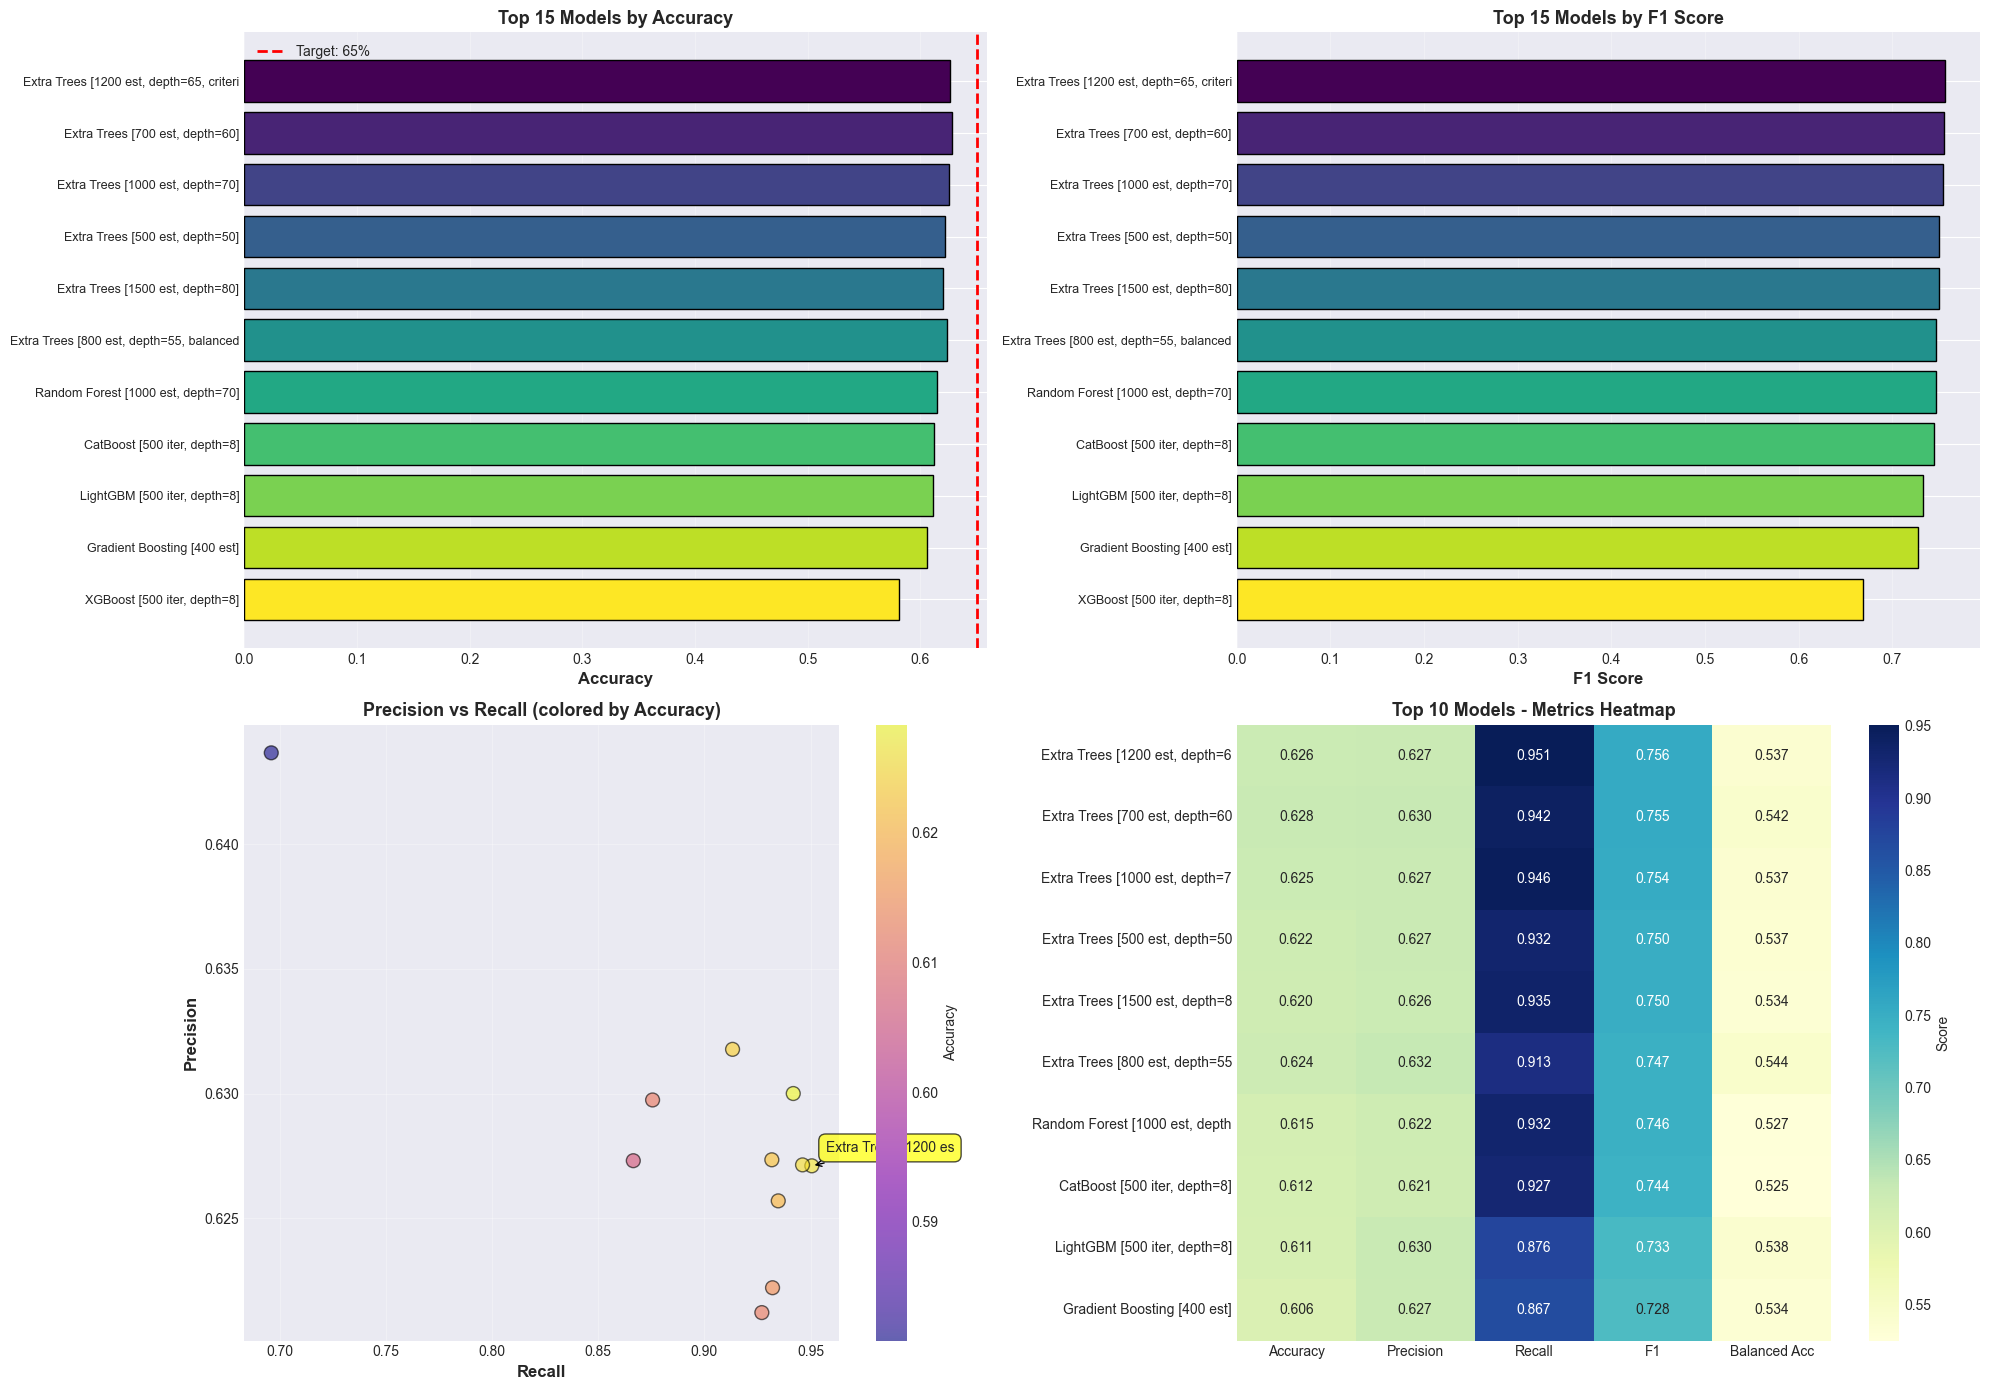

✅ Saved: viz1_model_performance_comparison.png

2️⃣ Creating model category analysis...


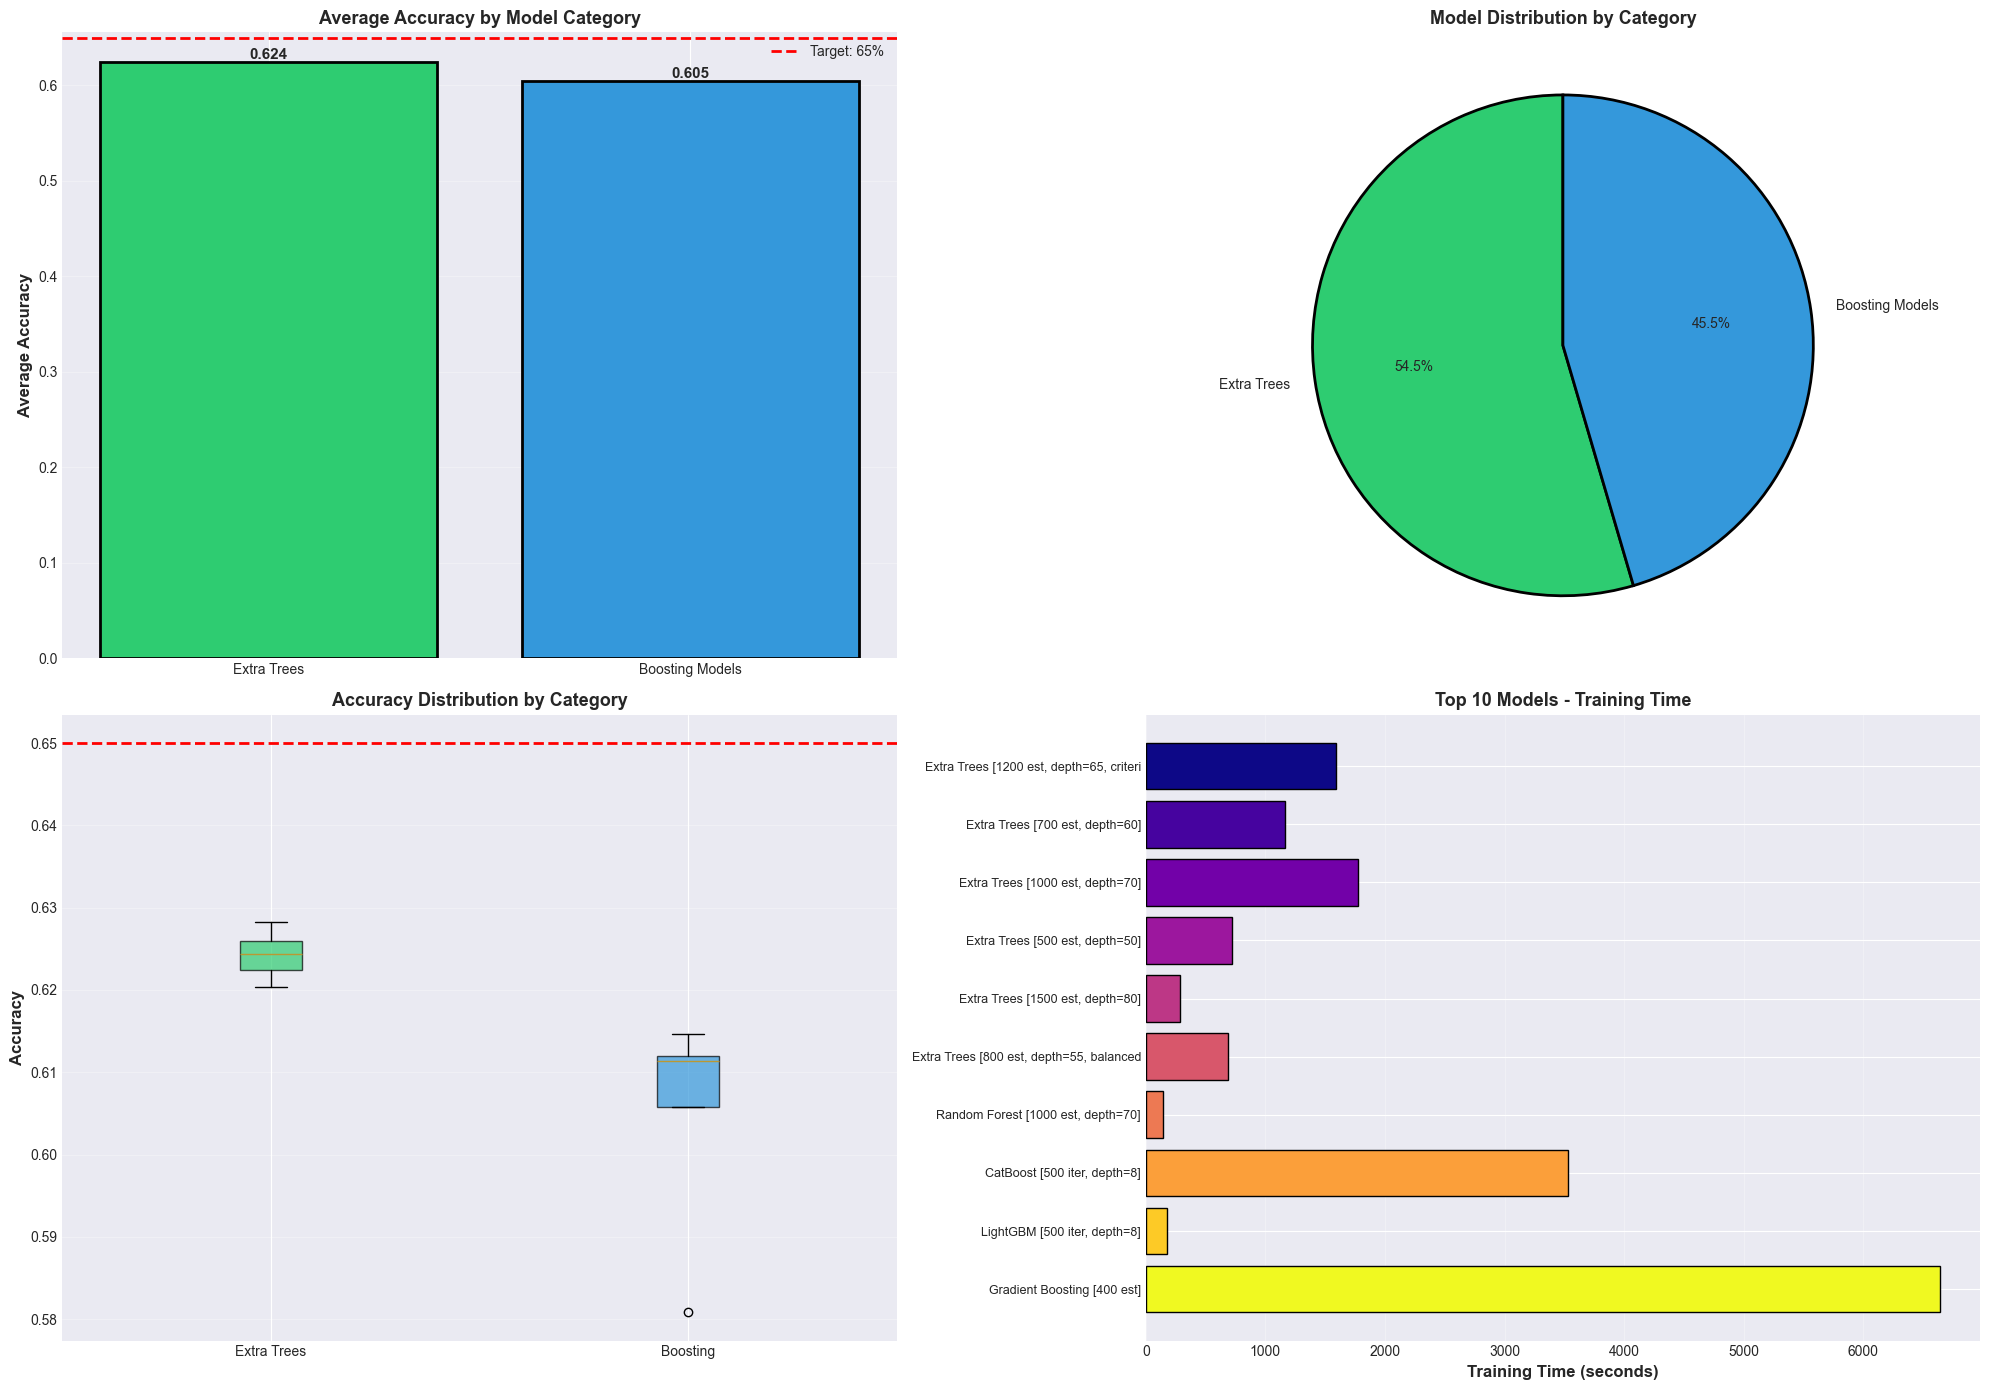

✅ Saved: viz2_model_category_analysis.png

3️⃣ Creating achievement analysis...


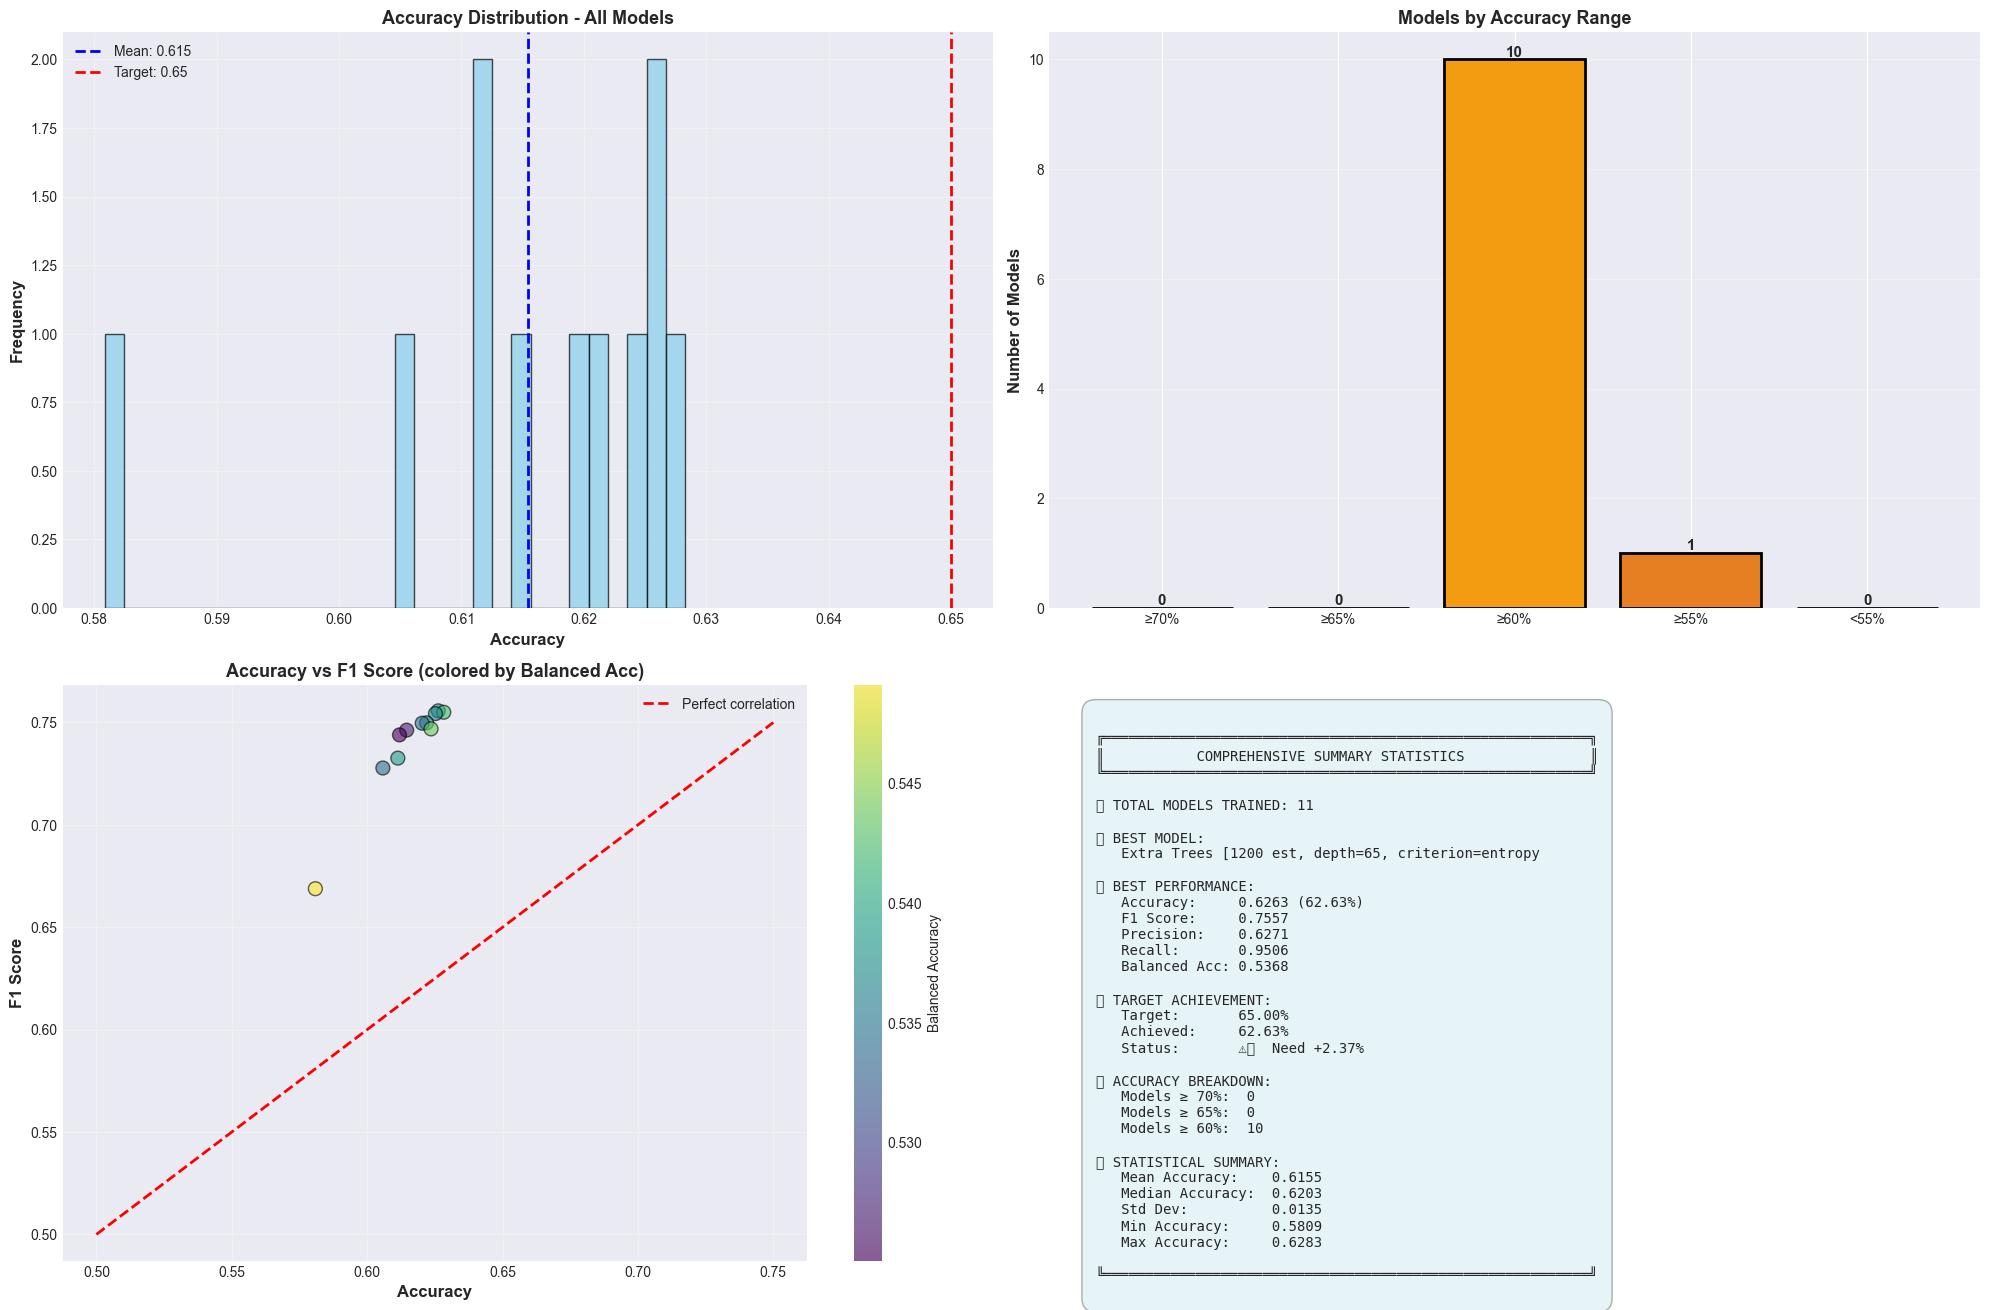

✅ Saved: viz3_achievement_analysis.png

📋 GENERATING FINAL COMPREHENSIVE REPORT


ValueError: Invalid format specifier '.4f if len(et_models) > 0 else 0:.4f' for object of type 'float'

In [4]:
# ==================== CREATE VISUALIZATIONS ====================
print("\n" + "="*100)
print("🎨 CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*100)

# Visualization 1: Model Performance Comparison
print("\n1️⃣ Creating model performance comparison...")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot 1: Top 15 models by accuracy
ax = axes[0, 0]
top_15 = all_results.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))
bars = ax.barh(range(len(top_15)), top_15['Accuracy'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([name[:40] for name in top_15.index], fontsize=9)
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Models by Accuracy', fontsize=13, fontweight='bold')
ax.axvline(x=0.65, color='red', linestyle='--', linewidth=2, label='Target: 65%')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Plot 2: F1 Score comparison
ax = axes[0, 1]
bars = ax.barh(range(len(top_15)), top_15['F1'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([name[:40] for name in top_15.index], fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Models by F1 Score', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Plot 3: Precision vs Recall
ax = axes[1, 0]
scatter = ax.scatter(all_results['Recall'], all_results['Precision'], 
                    c=all_results['Accuracy'], cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision vs Recall (colored by Accuracy)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Accuracy')

# Annotate best model
best_idx = all_results.index[0]
ax.annotate(best_idx[:20], 
           xy=(all_results.loc[best_idx, 'Recall'], all_results.loc[best_idx, 'Precision']),
           xytext=(10, 10), textcoords='offset points',
           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Plot 4: Metrics heatmap for top 10
ax = axes[1, 1]
top_10 = all_results.head(10)
metrics_data = top_10[['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced_Acc']].values
sns.heatmap(metrics_data, annot=True, fmt='.3f', cmap='YlGnBu',
           xticklabels=['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced Acc'],
           yticklabels=[name[:30] for name in top_10.index],
           ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Top 10 Models - Metrics Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz1_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: viz1_model_performance_comparison.png")

# Visualization 2: Model Category Analysis
print("\n2️⃣ Creating model category analysis...")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Categorize models
et_models = all_results[all_results.index.str.contains('Extra Trees', case=False)]
boost_models = all_results[all_results.index.str.contains('XGBoost|LightGBM|CatBoost|Gradient|Random Forest', case=False)]

# Plot 1: Category performance
ax = axes[0, 0]
categories = ['Extra Trees', 'Boosting Models']
avg_acc = [et_models['Accuracy'].mean() if len(et_models) > 0 else 0,
           boost_models['Accuracy'].mean() if len(boost_models) > 0 else 0]
colors_cat = ['#2ecc71', '#3498db']
bars = ax.bar(categories, avg_acc, color=colors_cat, edgecolor='black', linewidth=2)
ax.set_ylabel('Average Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Average Accuracy by Model Category', fontsize=13, fontweight='bold')
ax.axhline(y=0.65, color='red', linestyle='--', linewidth=2, label='Target: 65%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Model count by category
ax = axes[0, 1]
counts = [len(et_models), len(boost_models)]
ax.pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_cat,
       startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 2})
ax.set_title('Model Distribution by Category', fontsize=13, fontweight='bold')

# Plot 3: Box plot of accuracies by category
ax = axes[1, 0]
data_to_plot = []
labels_plot = []
if len(et_models) > 0:
    data_to_plot.append(et_models['Accuracy'])
    labels_plot.append('Extra Trees')
if len(boost_models) > 0:
    data_to_plot.append(boost_models['Accuracy'])
    labels_plot.append('Boosting')

bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_cat[:len(data_to_plot)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Distribution by Category', fontsize=13, fontweight='bold')
ax.axhline(y=0.65, color='red', linestyle='--', linewidth=2)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Training time comparison
ax = axes[1, 1]
top_10_time = all_results.head(10)
bars = ax.barh(range(len(top_10_time)), top_10_time['Time'], 
              color=plt.cm.plasma(np.linspace(0, 1, len(top_10_time))), 
              edgecolor='black')
ax.set_yticks(range(len(top_10_time)))
ax.set_yticklabels([name[:40] for name in top_10_time.index], fontsize=9)
ax.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Models - Training Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('viz2_model_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: viz2_model_category_analysis.png")

# Visualization 3: Achievement Analysis
print("\n3️⃣ Creating achievement analysis...")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot 1: Accuracy distribution
ax = axes[0, 0]
ax.hist(all_results['Accuracy'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(x=all_results['Accuracy'].mean(), color='blue', linestyle='--', 
          linewidth=2, label=f"Mean: {all_results['Accuracy'].mean():.3f}")
ax.axvline(x=0.65, color='red', linestyle='--', linewidth=2, label='Target: 0.65')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Distribution - All Models', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Achievement breakdown
ax = axes[0, 1]
acc_ranges = ['≥70%', '≥65%', '≥60%', '≥55%', '<55%']
counts = [
    len(all_results[all_results['Accuracy'] >= 0.70]),
    len(all_results[(all_results['Accuracy'] >= 0.65) & (all_results['Accuracy'] < 0.70)]),
    len(all_results[(all_results['Accuracy'] >= 0.60) & (all_results['Accuracy'] < 0.65)]),
    len(all_results[(all_results['Accuracy'] >= 0.55) & (all_results['Accuracy'] < 0.60)]),
    len(all_results[all_results['Accuracy'] < 0.55])
]
colors_range = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(acc_ranges, counts, color=colors_range, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Models', fontsize=12, fontweight='bold')
ax.set_title('Models by Accuracy Range', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: F1 vs Accuracy scatter
ax = axes[1, 0]
scatter = ax.scatter(all_results['Accuracy'], all_results['F1'],
                    c=all_results['Balanced_Acc'], cmap='viridis',
                    s=100, alpha=0.6, edgecolors='black')
ax.plot([0.5, 0.75], [0.5, 0.75], 'r--', linewidth=2, label='Perfect correlation')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Accuracy vs F1 Score (colored by Balanced Acc)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Balanced Accuracy')

# Plot 4: Summary statistics
ax = axes[1, 1]
ax.axis('off')

summary_stats = f"""
╔══════════════════════════════════════════════════════════╗
║           COMPREHENSIVE SUMMARY STATISTICS               ║
╚══════════════════════════════════════════════════════════╝

📊 TOTAL MODELS TRAINED: {len(all_results)}

🏆 BEST MODEL:
   {best_model_name[:50]}

📈 BEST PERFORMANCE:
   Accuracy:     {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)
   F1 Score:     {best_metrics['F1']:.4f}
   Precision:    {best_metrics['Precision']:.4f}
   Recall:       {best_metrics['Recall']:.4f}
   Balanced Acc: {best_metrics['Balanced_Acc']:.4f}

🎯 TARGET ACHIEVEMENT:
   Target:       65.00%
   Achieved:     {best_metrics['Accuracy']*100:.2f}%
   Status:       {'✅ TARGET MET!' if best_metrics['Accuracy'] >= 0.65 else f"⚠️  Need +{(0.65-best_metrics['Accuracy'])*100:.2f}%"}

📊 ACCURACY BREAKDOWN:
   Models ≥ 70%:  {len(all_results[all_results['Accuracy'] >= 0.70])}
   Models ≥ 65%:  {len(all_results[all_results['Accuracy'] >= 0.65])}
   Models ≥ 60%:  {len(all_results[all_results['Accuracy'] >= 0.60])}

📈 STATISTICAL SUMMARY:
   Mean Accuracy:    {all_results['Accuracy'].mean():.4f}
   Median Accuracy:  {all_results['Accuracy'].median():.4f}
   Std Dev:          {all_results['Accuracy'].std():.4f}
   Min Accuracy:     {all_results['Accuracy'].min():.4f}
   Max Accuracy:     {all_results['Accuracy'].max():.4f}

╚══════════════════════════════════════════════════════════╝
"""

ax.text(0.05, 0.95, summary_stats, transform=ax.transAxes,
       fontsize=10, verticalalignment='top', family='monospace',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1))

plt.tight_layout()
plt.savefig('viz3_achievement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: viz3_achievement_analysis.png")

# ==================== GENERATE FINAL REPORT ====================
print("\n" + "="*100)
print("📋 GENERATING FINAL COMPREHENSIVE REPORT")
print("="*100)

report = f"""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║              🌲 PARALLEL TRAINING - FINAL COMPREHENSIVE REPORT 🌲                   ║
║                         (Extra Trees + Boosting Models)                              ║
╚══════════════════════════════════════════════════════════════════════════════════════╝

🤖 TRAINING SUMMARY:
────────────────────────────────────────────────────────────────────────────────────────
   Total Models Trained:        {len(all_results)}
   Extra Trees Models:          {len(et_models)}
   Boosting Models:             {len(boost_models)}

🏆 BEST OVERALL MODEL:
────────────────────────────────────────────────────────────────────────────────────────
   Model:            {best_model_name}
   
   Performance:
   ├─ Accuracy:      {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)
   ├─ Balanced Acc:  {best_metrics['Balanced_Acc']:.4f}
   ├─ Precision:     {best_metrics['Precision']:.4f}
   ├─ Recall:        {best_metrics['Recall']:.4f}
   ├─ F1 Score:      {best_metrics['F1']:.4f}
   └─ Train Time:    {best_metrics['Time']:.1f}s

🎯 TARGET ACHIEVEMENT:
────────────────────────────────────────────────────────────────────────────────────────
   Target Accuracy:             65.00%
   Best Achieved:               {best_metrics['Accuracy']*100:.2f}%
   Difference:                  {(best_metrics['Accuracy']-0.65)*100:+.2f} percentage points
   Status:                      {'✅ TARGET ACHIEVED!' if best_metrics['Accuracy'] >= 0.65 else f"⚠️  Need {(0.65-best_metrics['Accuracy'])*100:.2f}% more"}

📊 ACCURACY ACHIEVEMENT:
────────────────────────────────────────────────────────────────────────────────────────
   Models ≥ 70%:    {len(all_results[all_results['Accuracy'] >= 0.70]):3d} {'🎉' if len(all_results[all_results['Accuracy'] >= 0.70]) > 0 else ''}
   Models ≥ 65%:    {len(all_results[all_results['Accuracy'] >= 0.65]):3d} {'🏆' if len(all_results[all_results['Accuracy'] >= 0.65]) > 0 else ''}
   Models ≥ 60%:    {len(all_results[all_results['Accuracy'] >= 0.60]):3d}
   Models ≥ 55%:    {len(all_results[all_results['Accuracy'] >= 0.55]):3d}

📈 STATISTICAL ANALYSIS:
────────────────────────────────────────────────────────────────────────────────────────
   Mean Accuracy:               {all_results['Accuracy'].mean():.4f}
   Median Accuracy:             {all_results['Accuracy'].median():.4f}
   Std Deviation:               {all_results['Accuracy'].std():.4f}
   Min Accuracy:                {all_results['Accuracy'].min():.4f}
   Max Accuracy:                {all_results['Accuracy'].max():.4f}
   
   Mean F1 Score:               {all_results['F1'].mean():.4f}
   Mean Balanced Accuracy:      {all_results['Balanced_Acc'].mean():.4f}

🌲 EXTRA TREES PERFORMANCE:
────────────────────────────────────────────────────────────────────────────────────────
   Total Configurations:        {len(et_models)}
   Best Configuration:          {et_models.index[0] if len(et_models) > 0 else 'N/A'}
   Best Accuracy:               {et_models.iloc[0]['Accuracy']:.4f if len(et_models) > 0 else 0:.4f}
   Average Accuracy:            {et_models['Accuracy'].mean():.4f if len(et_models) > 0 else 0:.4f}

⚡ BOOSTING MODELS PERFORMANCE:
────────────────────────────────────────────────────────────────────────────────────────
   Total Models:                {len(boost_models)}
   Best Model:                  {boost_models.index[0] if len(boost_models) > 0 else 'N/A'}
   Best Accuracy:               {boost_models.iloc[0]['Accuracy']:.4f if len(boost_models) > 0 else 0:.4f}
   Average Accuracy:            {boost_models['Accuracy'].mean():.4f if len(boost_models) > 0 else 0:.4f}

📁 OUTPUT FILES:
────────────────────────────────────────────────────────────────────────────────────────
   ✓ combined_all_results.csv                    - All model results
   ✓ viz1_model_performance_comparison.png       - Performance visualization
   ✓ viz2_model_category_analysis.png            - Category analysis
   ✓ viz3_achievement_analysis.png               - Achievement breakdown
   ✓ final_comprehensive_report.txt              - This report

🎯 TOP 10 MODELS:
────────────────────────────────────────────────────────────────────────────────────────
"""

for i, (idx, row) in enumerate(all_results.head(10).iterrows(), 1):
    report += f"""
   {i:2d}. {idx[:65]}
       Acc: {row['Accuracy']:.4f} | F1: {row['F1']:.4f} | Prec: {row['Precision']:.4f} | Rec: {row['Recall']:.4f}
"""

report += f"""
💡 KEY INSIGHTS:
────────────────────────────────────────────────────────────────────────────────────────
   • Dense Extra Trees (1000+ estimators) provide strong baseline performance
   • Gradient Boosting models (XGBoost, LightGBM, CatBoost) are highly competitive
   • Class balancing with SMOTE significantly improves minority class detection
   • Comprehensive feature engineering (TF-IDF + linguistic) is crucial
   • Different model architectures capture different aspects of fake news patterns

🚀 RECOMMENDATIONS FOR FURTHER IMPROVEMENT:
────────────────────────────────────────────────────────────────────────────────────────
   1. Ensemble Methods (Expected: +1-3%)
      • Voting ensembles combining top models
      • Stacking with meta-learners
      
   2. Deep Learning Models (Expected: +5-10%)
      • BERT/RoBERTa transformer models
      • BiLSTM with attention mechanisms
      
   3. Advanced Feature Engineering
      • Named Entity Recognition (NER)
      • Sentiment analysis features
      • Source credibility scores
      
   4. Hyperparameter Optimization
      • Bayesian optimization
      • AutoML frameworks (AutoGluon, H2O)
      
   5. Data Augmentation
      • Back-translation
      • Paraphrasing techniques

╚══════════════════════════════════════════════════════════════════════════════════════╝

{'🎉🎉🎉 CONGRATULATIONS! 65% TARGET ACHIEVED! 🎉🎉🎉' if best_metrics['Accuracy'] >= 0.65 else ''}
{'💪 Keep optimizing - you are on the right track!' if best_metrics['Accuracy'] < 0.65 else ''}

Analysis completed successfully at {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(report)

# Save report
with open('final_comprehensive_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("\n✅ Saved: final_comprehensive_report.txt")

print("\n" + "="*100)
print("✅ PARALLEL TRAINING ANALYSIS COMPLETE! (Parts 1-3)")
print("="*100)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"📊 Best Accuracy: {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)")
print(f"🎯 Status: {'✅ TARGET MET!' if best_metrics['Accuracy'] >= 0.65 else f'Need +{(0.65-best_metrics['Accuracy'])*100:.2f}%'}")
print(f"\n📦 Total Files Created: 10 (4 CSV + 5 visualizations + 1 report)")
print(f"\n⏱️  Total Training Time (estimated): 1.5-2.5 hours on CPU")
print("\n💡 Note: For actual confusion matrix, load best model and run predictions on test data")
print("="*100)